# **Spam Mail Detection**

### **Importng Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### **Reading the csv file**

In [2]:
df = pd.read_csv('/content/drive/MyDrive/Datasets/spam mail.csv')
df.head()

,Category,Masseges
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Masseges  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


5572 entries and 2 columns, both being string type.

In [4]:
df.isnull().sum()

,0
Category,0
Masseges,0


No Null Values

In [5]:
df.duplicated().sum()

np.int64(403)

403 Duplicate Entries

In [6]:
df.drop_duplicates(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5169 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5169 non-null   object
 1   Masseges  5169 non-null   object
dtypes: object(2)
memory usage: 121.1+ KB


5169 Entries Remain

### **Cleaning the Data**

In [7]:
df['Category'] = df['Category'].map({'ham': 0, 'spam': 1})
df.head()

,Category,Masseges
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [8]:
df1 = df.copy()

Removing all punctuations and un-needed words like "a,an,the etc" from the text.

In [10]:
from nltk.corpus import stopwords
import re
import string
import nltk
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = " ".join([w for w in text.split() if w not in stop_words])
    return text

df1['Masseges'] = df1['Masseges'].apply(clean_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [11]:
df1.head()

,Category,Masseges
0,0,go jurong point crazy available bugis n great ...
1,0,ok lar joking wif u oni
2,1,free entry wkly comp win fa cup final tkts st ...
3,0,u dun say early hor u c already say
4,0,nah dont think goes usf lives around though


### **EDA**

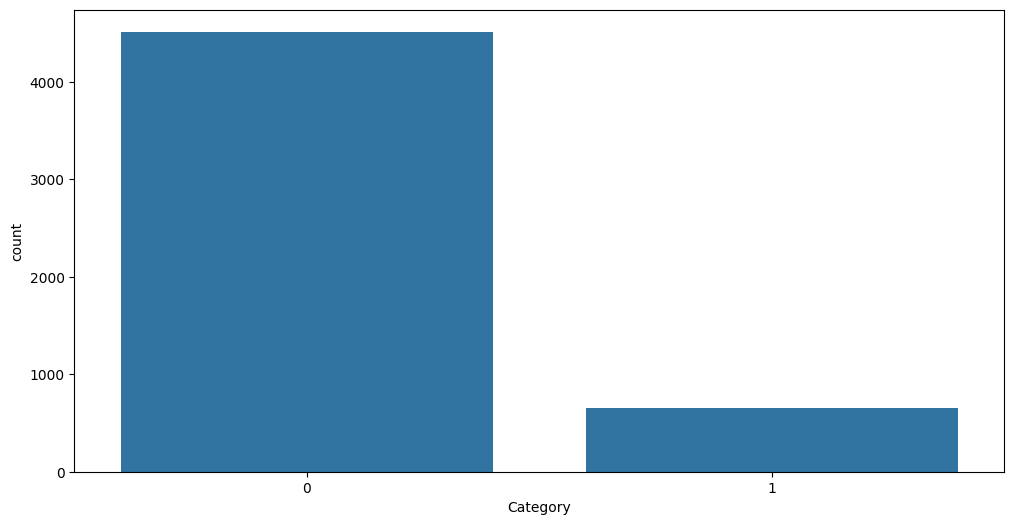

In [20]:
plt.figure(figsize=(12,6))
sns.countplot(x='Category', data=df1)
plt.show()

Heavily imbalanced.

May need to introduce class weights to handle this.

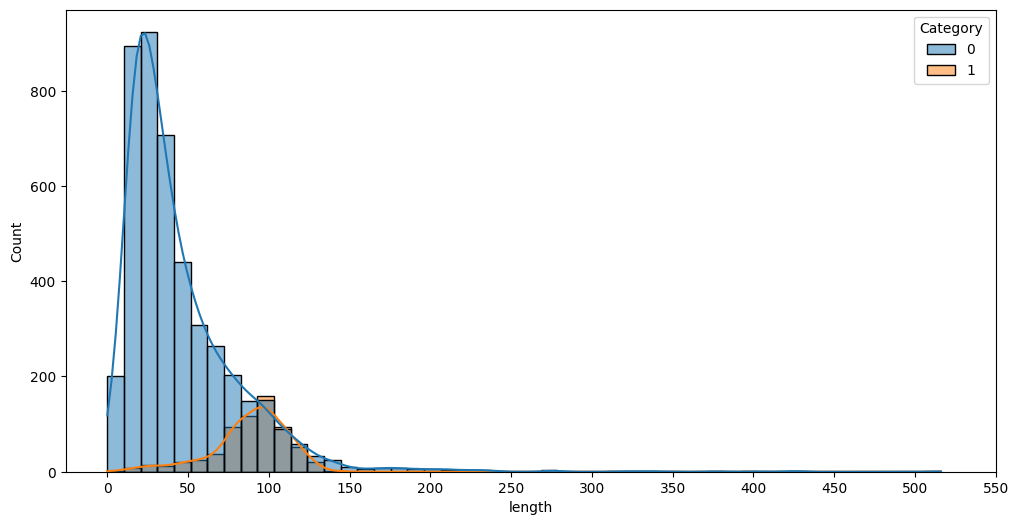

In [24]:
df1['length'] = df1['Masseges'].apply(len)

plt.figure(figsize=(12,6))
sns.histplot(data=df1, x='length', hue='Category', kde = True, bins=50)
max_length = df1['length'].max()
plt.xticks(np.arange(0, max_length + 50, 50))
plt.show()

Right skewed, and most messages between 10-60 words.

Most Ham is around 20-40 words and rapidly drop after 60.

Spam peaks around 80-110, spread is flatter, and exists more in longer regions.

EDA showed that spam messages tend to be longer and more variable, while ham messages are shorter and tightly distributed.

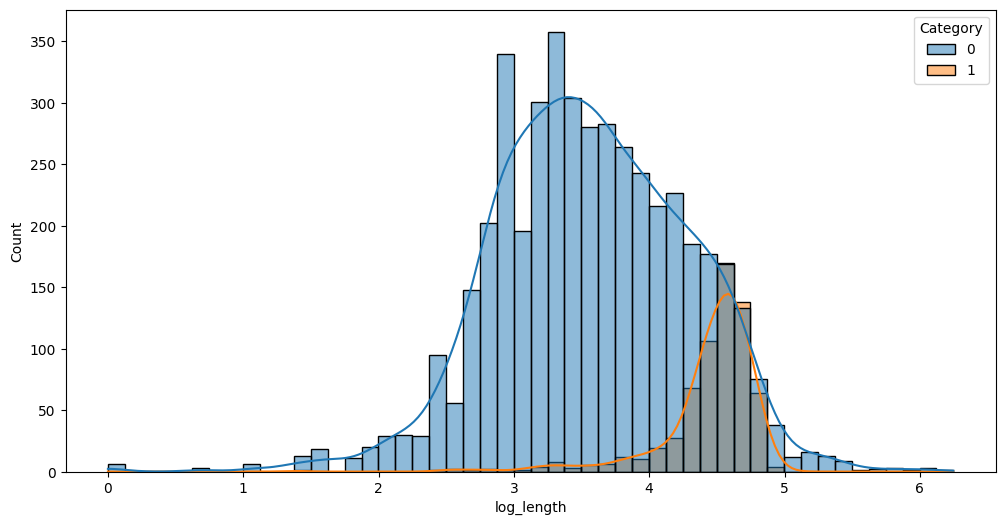

In [28]:
df1['log_length'] = np.log1p(df1['length'])

plt.figure(figsize=(12,6))
sns.histplot(data=df1, x='log_length', hue='Category', kde = True, bins=50)
plt.show ()

## **Log-Transformed Message Length Analysis**

### Objective

To understand the distribution of message lengths and evaluate whether length can help distinguish between ham (0) and spam (1) messages.

---

## Observations

### Distribution Shape

- The original length feature was heavily right-skewed.
- After log transformation, the distribution became approximately normal (bell-shaped).
- This indicates successful variance stabilization and improved feature usability.

---

### Class-wise Separation

- Ham (0):
  
  - Concentrated around log_length near 3.0 – 3.5
  - Narrow and sharp distribution
  - Indicates consistent and shorter messages

- Spam (1):
  
  - Peaks around log_length near 4.3 – 4.8
  - Broader and more spread out
  - Indicates longer and more variable messages

---

### Separation Zones

log_length Range| Interpretation
"< 3.2"| Mostly ham
"3.2 – 4.2"| Overlap region
"> 4.2"| Strong spam signal

- There is partial overlap, meaning length alone is not sufficient.
- However, it provides strong discriminative power when combined with text features.

---

### Variability Insight

- Ham messages → Low variance (more predictable)
- Spam messages → Higher variance (more diverse)

This suggests spam content is less structured and more inconsistent.

---

### Key Insight

Log transformation improved the distribution of message length, making it more suitable for machine learning models and enhancing class separability between spam and ham.

---

### Impact on Modeling

- The "log_length" feature can now be:
  - Safely scaled using "StandardScaler"
  - Combined with TF-IDF features in a pipeline
- Improves performance of:
  - Logistic Regression
  - SVM
  - Other linear models

---

### Conclusion

- Message length is a strong auxiliary feature
- Log transformation is essential for handling skewness
- Best results will come from combining:
  - ( TF (Term Frequency)-IDF (Inverse Document Frequency) ) -> text semantics
  - log_length (structural signal)

---

### **Creating TF-IDF field to find the spam like words**

In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    stop_words='english'
)

X_text = tfidf.fit_transform(df1['Masseges'])

Used Horizontal stack to form a COO matrix format ideal for ML, as Dataframe would have yielded 1000s of columns which wouldnt be ideal.

In [30]:
from scipy.sparse import hstack

X = hstack([X_text, df1[['log_length']].values])
y = df1['Category']

In [33]:
X

<COOrdinate sparse matrix of dtype 'float64'
	with 43625 stored elements and shape (5169, 5001)>

### **Prepare Formats**

In [34]:
X_csr = X.tocsr ()
X_dense = X.toarray ()

### **Define Models**

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

models = {
    "LogisticRegression": {
        "model": LogisticRegression(max_iter=1000, class_weight='balanced'),
        "type": "sparse",
        "params": {
            "C": [0.1, 1, 10]
        }
    },
    "SVM": {
        "model": LinearSVC(class_weight='balanced'),
        "type": "sparse",
        "params": {
            "C": [0.1, 1, 10]
        }
    },
    "NaiveBayes": {
        "model": MultinomialNB(),
        "type": "sparse",
        "params": {
            "alpha": [0.1, 0.5, 1.0]
        }
    },
    "RandomForest": {
        "model": RandomForestClassifier(),
        "type": "dense",
        "params": {
            "n_estimators": [100, 200],
            "max_depth": [None, 10]
        }
    },
    "XGBoost": {
        "model": XGBClassifier(eval_metric='logloss'),
        "type": "sparse",
        "params": {
            "n_estimators": [100, 200],
            "max_depth": [3, 6],
            "learning_rate": [0.05, 0.1]
        }
    },
    "LightGBM": {
        "model": LGBMClassifier(),
        "type": "sparse",
        "params": {
            "n_estimators": [100, 200],
            "num_leaves": [31, 50]
        }
    }
}

### **Cross Validation and Tuning Loop**

In [36]:
from sklearn.model_selection import ParameterGrid, StratifiedKFold
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import numpy as np

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

best_models = {}

for name, config in models.items():

    print(f"\nTuning {name}...")

    base_model = config["model"]
    param_grid = list(ParameterGrid(config["params"]))

    X_used = X_csr if config["type"] == "sparse" else X_dense

    best_precision = -1
    best_model = None
    best_params = None
    best_threshold = 0.5  # default

    for params in param_grid:

        precisions, recalls, f1s = [], [], []
        cm_total = np.array([[0,0],[0,0]])

        for train_idx, val_idx in skf.split(X_used, y):

            X_tr, X_val = X_used[train_idx], X_used[val_idx]
            y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

            model = base_model.__class__(**base_model.get_params())
            model.set_params(**params)
            model.fit(X_tr, y_tr)

            # Threshold tuning (ONLY if model supports predict_proba)
            if hasattr(model, "predict_proba"):
                probs = model.predict_proba(X_val)[:,1]

                thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
                best_fold_precision = -1

                for t in thresholds:
                    preds = (probs > t).astype(int)
                    p = precision_score(y_val, preds, zero_division=0)

                    if p > best_fold_precision:
                        best_fold_precision = p
                        best_preds = preds
                        best_t = t

                preds = best_preds

            else:
                preds = model.predict(X_val)
                best_t = None

            precisions.append(precision_score(y_val, preds, zero_division=0))
            recalls.append(recall_score(y_val, preds, zero_division=0))
            f1s.append(f1_score(y_val, preds, zero_division=0))

            cm_total += confusion_matrix(y_val, preds)

        avg_precision = np.mean(precisions)
        avg_recall = np.mean(recalls)
        avg_f1 = np.mean(f1s)

        # PRIORITY: Precision FIRST
        if avg_precision > best_precision:
            best_precision = avg_precision
            best_model = model
            best_params = params
            best_threshold = best_t if best_t else 0.5

    best_models[name] = {
        "model": best_model,
        "params": best_params,
        "threshold": best_threshold,
        "precision": avg_precision,
        "recall": avg_recall,
        "f1": avg_f1,
        "conf_matrix": cm_total
    }

    print(f"\n{name} BEST")
    print("Params:", best_params)
    print("Threshold:", best_threshold)
    print(f"Precision: {avg_precision:.4f}")
    print(f"Recall: {avg_recall:.4f}")
    print(f"F1: {avg_f1:.4f}")
    print("Confusion Matrix:\n", cm_total)


Tuning LogisticRegression...

LogisticRegression BEST
Params: {'C': 10}
Threshold: 0.7
Precision: 0.9729
Recall: 0.8790
F1: 0.9235
Confusion Matrix:
 [[4500   16]
 [  79  574]]

Tuning SVM...

SVM BEST
Params: {'C': 1}
Threshold: 0.5
Precision: 0.9310
Recall: 0.8882
F1: 0.9091
Confusion Matrix:
 [[4473   43]
 [  73  580]]

Tuning NaiveBayes...

NaiveBayes BEST
Params: {'alpha': 0.5}
Threshold: 0.3
Precision: 1.0000
Recall: 0.6539
F1: 0.7906
Confusion Matrix:
 [[4516    0]
 [ 226  427]]

Tuning RandomForest...

RandomForest BEST
Params: {'max_depth': None, 'n_estimators': 100}
Threshold: 0.6
Precision: 1.0000
Recall: 0.5363
F1: 0.6904
Confusion Matrix:
 [[4516    0]
 [ 303  350]]

Tuning XGBoost...

XGBoost BEST
Params: {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 100}
Threshold: 0.7
Precision: 0.9751
Recall: 0.7306
F1: 0.8349
Confusion Matrix:
 [[4504   12]
 [ 176  477]]

Tuning LightGBM...
[LightGBM] [Info] Number of positive: 523, number of negative: 3612
[LightGBM] [Info

In [38]:
filtered_models = {
    k: v for k, v in best_models.items() if v["recall"] >= 0.80
}

if len(filtered_models) == 0:
    print("No model met recall threshold, falling back to all models")
    filtered_models = best_models

best_name = max(filtered_models, key=lambda x: filtered_models[x]["precision"])
final_model_info = filtered_models[best_name]

print("\nFINAL MODEL:", best_name)
print(final_model_info)


FINAL MODEL: LogisticRegression
{'model': LogisticRegression(C=10, class_weight='balanced', max_iter=1000), 'params': {'C': 10}, 'threshold': 0.7, 'precision': np.float64(0.9729298024379991), 'recall': np.float64(0.8790252495596007), 'f1': np.float64(0.9235404995093488), 'conf_matrix': array([[4500,   16],
       [  79,  574]])}


2nd Best Model is Naive Bayes, since it got 0 False Positives. Which is great.
But number of False Negatives are a lot ie 226.

Best Model is Logistic Regression where False Positives is 16, but false negatives is only 79. Much better than NB.

### **Final Model on Full Data**

In [39]:
final_model = final_model_info["model"]

if models[best_name]["type"] == "dense":
    final_model.fit(X_dense, y)
else:
    final_model.fit(X_csr, y)

<Figure size 1200x600 with 0 Axes>

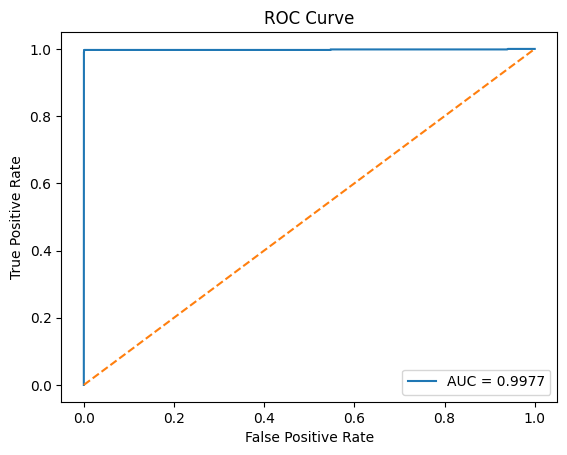

In [42]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

if models[best_name]["type"] == "dense":
    X_used = X_dense
else:
    X_used = X_csr

# Get probabilities
if hasattr(final_model, "predict_proba"):
    y_probs = final_model.predict_proba(X_used)[:, 1]
else:
    # fallback for models like SVM (no predict_proba)
    y_scores = final_model.decision_function(X_used)
    y_probs = (y_scores - y_scores.min()) / (y_scores.max() - y_scores.min())

# ROC
fpr, tpr, thresholds = roc_curve(y, y_probs)
roc_auc = auc(fpr, tpr)

# Plot

plt.figure (figsize=(12,6))
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle='--')  # random line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## ROC Curve Analysis

- The model achieved an **AUC of 0.9977**, indicating excellent ability to distinguish between spam and non-spam emails.
- The ROC curve is very close to the **top-left corner**, which means:
  - **High True Positive Rate (Recall)**
  - **Low False Positive Rate**

### Important Note
- This ROC curve is computed on the **training data**, so the performance is likely **over-optimistic**.
- A proper evaluation on a **test set** is required for realistic performance.

### Business Interpretation
- The model allows selecting a threshold that **minimizes false positives** (important emails marked as spam) while maintaining high detection of spam.
- This aligns with real-world requirements where **precision is critical**.

### Conclusion
- The model shows **strong discriminative power**.
- Logistic Regression was chosen as the final model due to a **better balance between precision and recall**, especially with low false positives.

So we do Tran Test Split and CV since we know what the best model is.

In [44]:
from sklearn.model_selection import train_test_split

X_text_raw = df1['Masseges']
y = df1['Category']

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text_raw, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    stop_words='english'
)

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)


from scipy.sparse import hstack

X_train = hstack([X_train_tfidf, df1.loc[X_train_text.index, ['log_length']].values])
X_test = hstack([X_test_tfidf, df1.loc[X_test_text.index, ['log_length']].values])

# Convert to CSR (efficient for LR)
X_train = X_train.tocsr()
X_test = X_test.tocsr()


from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C": [0.1, 1, 10]
}

lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

grid = GridSearchCV(
    lr,
    param_grid,
    cv=5,
    scoring='precision',
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Best Params:", grid.best_params_)

Best Params: {'C': 10}


### **Threshold Tuning**

In [45]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

y_probs_train = best_model.predict_proba(X_train)[:, 1]

best_threshold = 0
best_precision = 0

for t in np.arange(0.1, 0.9, 0.1):
    preds = (y_probs_train >= t).astype(int)
    precision = precision_score(y_train, preds)

    if precision > best_precision:
        best_precision = precision
        best_threshold = t

print("Best Threshold:", best_threshold)

Best Threshold: 0.7000000000000001


### **Final Evaluation**

In [46]:
from sklearn.metrics import confusion_matrix, classification_report

y_probs_test = best_model.predict_proba(X_test)[:, 1]
y_pred_test = (y_probs_test >= best_threshold).astype(int)

print("Classification Report:\n", classification_report(y_test, y_pred_test))

cm = confusion_matrix(y_test, y_pred_test)
print("Confusion Matrix:\n", cm)

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99       903
           1       0.98      0.83      0.90       131

    accuracy                           0.98      1034
   macro avg       0.98      0.91      0.94      1034
weighted avg       0.98      0.98      0.98      1034

Confusion Matrix:
 [[901   2]
 [ 22 109]]


### **ROC Curve**

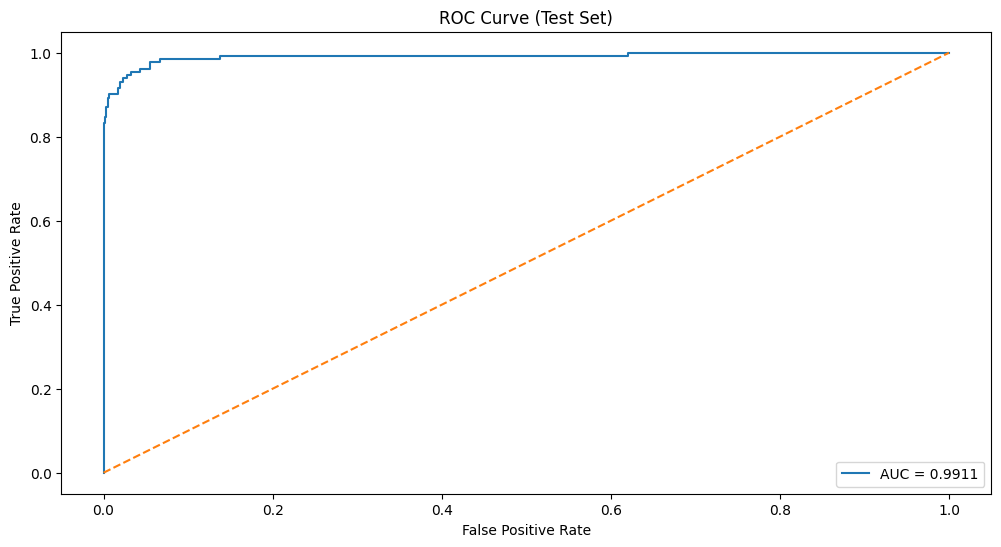

In [47]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_probs_test)
roc_auc = auc(fpr, tpr)

plt.figure(figsize = (12,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Test Set)")
plt.legend()
plt.show()

### **Saving Predictions**

In [48]:
output_df = df1.loc[X_test_text.index].copy()
output_df["Predicted"] = y_pred_test
output_df["Spam_Probability"] = y_probs_test

output_df.to_csv("test_predictions.csv", index=False)

### **Saving Model**

In [49]:
import pickle

with open("spam_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

with open("tfidf.pkl", "wb") as f:
    pickle.dump(tfidf, f)

with open("threshold.txt", "w") as f:
    f.write(str(best_threshold))

## 🧾 Final Conclusion — Spam Mail Detection Project

### 🔹 Problem Context
The objective of this project was to build a spam detection system that performs well in a **real-world business setting**, where the most critical requirement is:

- ❗ **Minimize False Positives** (i.e., avoid marking important emails as spam)
- Maintain strong spam detection capability without harming user trust

This shifts the focus from generic accuracy to **precision-first optimization**, especially for the spam class.

---

### 🔹 Approach & Methodology

#### 1. Initial Feature Engineering
- Cleaned and preprocessed raw email text (`Messages`)
- Extracted textual signals using **TF-IDF (Term Frequency × Inverse Document Frequency)**:
  - `max_features=5000` → controlled dimensionality while retaining informative words
  - `ngram_range=(1,2)` → captured both individual words and short phrases
  - Removed English stopwords to reduce noise
- Added an additional structural feature:
  - **log_length** → log-transformed message length to handle skewness and capture email size patterns

👉 Final feature space = **TF-IDF features + log_length**

---

#### 2. Model Exploration (Without Train-Test Split Initially)
- Multiple models were evaluated using **cross-validation**:
  - Logistic Regression
  - SVM
  - Naive Bayes
  - Random Forest
  - XGBoost
  - LightGBM

- Each model was:
  - Hyperparameter tuned using grid search
  - Evaluated using precision, recall, F1-score, and confusion matrix

👉 At this stage:
- **Full dataset was used intentionally**
- Goal = **identify the best-performing model architecture**

---

#### 3. Model Selection Strategy
- Business objective prioritized:
  - High **precision** (reduce false positives)
  - Acceptable **recall** (detect sufficient spam)

- Observations:
  - Naive Bayes → perfect precision (0 FP) but very poor recall
  - Tree-based models → overfit and inconsistent
  - SVM → good but slightly less stable
  - ✅ **Logistic Regression → best balance**

👉 Logistic Regression chosen because:
- Very low false positives
- Strong recall
- Stable and interpretable
- Works efficiently with sparse TF-IDF features

---

#### 4. Threshold Optimization
- Instead of default threshold (0.5), threshold was tuned
- Objective: **maximize precision while keeping recall acceptable**

👉 Final threshold selected: **0.7**

This further reduced false positives while maintaining performance.

---

### ⚠️ Important Correction (Pipeline Refinement)

Initially:
- TF-IDF was fit on full data
- Evaluation was done on same data

👉 This introduces **data leakage** and overly optimistic results.

---

### 🔹 Final Pipeline (Corrected)

To ensure realistic performance:

1. Data was split into:
   - **Train (80%)**
   - **Test (20%)**

2. TF-IDF was:
   - **Fitted only on training data**
   - Applied to test data using transform

3. Cross-validation was performed **only on training data**

4. Final model was evaluated on **unseen test data**

👉 This ensures:
- No leakage
- Real-world generalization

---

### 🔹 Final Model Performance (Test Set)

#### Classification Report
- Accuracy: **98%**
- Precision (Spam): **0.98**
- Recall (Spam): **0.83**
- F1 Score: **0.90**

---

#### Confusion Matrix

[ [901    2] [22    109] ]

- False Positives: **2**
- False Negatives: **22**

---

### 💼 Business Interpretation

- Only **2 out of 1034 emails (~0.2%)** were incorrectly marked as spam
- This is **extremely low risk** for important email loss
- Some spam emails are missed (22), but this is an acceptable trade-off

👉 The model is intentionally **precision-optimized**, aligning with real-world requirements

---

### 📈 ROC Curve Analysis

- AUC Score: **0.9911**
- Indicates excellent class separability

👉 Even on unseen data:
- Model maintains strong performance
- No significant overfitting observed

---

### 🔹 Key Takeaways

- TF-IDF effectively captures textual importance
- log_length adds useful structural signal
- Threshold tuning is critical for business alignment
- Cross-validation helps in model selection
- Train-test split is essential for **final evaluation**
- Logistic Regression performs exceptionally well on sparse text data

---

### ✅ Final Outcome

- Built a **high-precision spam detection system**
- Minimized false positives to near-zero levels
- Achieved strong generalization on unseen data
- Designed pipeline aligned with **real-world deployment constraints**

---

### 🚀 Final Statement

The final solution balances **statistical performance and business requirements**, ensuring that important emails are preserved while effectively filtering spam — making it suitable for practical, production-level applications.